# UAV DRONE DETECTION AND TRACKING

> Detect and track UAV drones in video using a deep learning object detector and a Kalman filter.


# SETUP AND CONFIGURATION

In [3]:
%pip install ultralytics filterpy opencv-python numpy pandas pyarrow yt-dlp tqdm datasets huggingface_hub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Import all required libraries
import os
import sys
import json
import subprocess
from pathlib import Path
from typing import List, Dict, Any, Tuple, Optional
from collections import deque

import cv2
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

from filterpy.kalman import KalmanFilter
from ultralytics import YOLO

# for displaying images in Jupyter Notebook
from IPython.display import display, Image as IPImage, Video, HTML
import matplotlib.pyplot as plt
%matplotlib inline

import torch

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Configurations - All settings in one place

class config:
    BASE_DIR = Path(".").resolve()
    VIDEOS_DIR = BASE_DIR / "videos"
    FRAMES_DIR = BASE_DIR / "frames"
    DETECTIONS_DIR = BASE_DIR / "detections"
    OUTPUT_DIR = BASE_DIR / "output"
    MODELS_DIR = BASE_DIR / "models"
    DATA_DIR = BASE_DIR / "data"

    FRAME_RATE=5 # Extract 5 frames per second from videos

    YOLO_MODEL= "yolov8n.pt" # Using the nano version for speed, can switch to larger models if needed
    CONFIDENCE_THRESHOLD=0.1 # Minimum confidence for detections to be considered valid
    IOU_THRESHOLD=0.5 # IoU threshold for Non-Maximum Suppression

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # Use GPU if available, otherwise CPU

    # Kalman Filter Settings
    # Process Noise (Q)
    PROCESS_NOISE_POSITION=1.0
    PROCESS_NOISE_VELOCITY=0.1

    # Measurement Noise (R)
    MEASUREMENT_NOISE = 10.0

    # Initial Uncertainty (P)
    INITIAL_UNCERTAINTY_POSITION=100.0
    INITIAL_UNCERTAINTY_VELOCITY=10.0

    # Missing detection handling
    MAX_FRAMES_TO_SKIP = 10

    # Visualization settings
    BOX_COLOR = (0, 255, 0) # Green for bounding boxes
    TRAJECTORY_COLOR = (255, 0, 0) # Red for trajectories
    BOX_THICKNESS = 2
    TRAJECTORY_THICKNESS = 2
    TRAJECTORY_LENGTH = 50

    # Output Video
    OUTPUT_FPS = 5
    OUTPUT_CODEC= "mp4v"

    #Test Videos
    TEST_VIDEOS = [
        {
            "url": "https://www.youtube.com/watch?v=DhmZ6W1UAv4",
            "filename": "drone_video_1.mp4"
        },
        {
            "url": "https://www.youtube.com/watch?v=YrydHPwRelI",
            "filename": "drone_video_2.mp4"
        }
    ]

    @classmethod
    def create_directories(cls):
        for dir_path in [cls.VIDEOS_DIR, cls.FRAMES_DIR, cls.DETECTIONS_DIR,
                         cls.OUTPUT_DIR, cls.MODELS_DIR, cls.DATA_DIR]:
            dir_path.mkdir(parents=True, exist_ok=True)
        print(" All directories created")

Config=config()
Config.create_directories()

print(f"\nProject Directory: {Config.BASE_DIR}")


 All directories created

Project Directory: /workspaces/eng-ai-agents/assignments/assignments-3


# Step 1: Download Test Videos and Extract Frames

In [ ]:
def check_dependencies():
    """Verify that yt-dlp and ffmpeg are installed."""
    print("Checking dependencies...")

    # Check yt-dlp via Python module (works regardless of PATH)
    try:
        result = subprocess.run([sys.executable, "-m", "yt_dlp", "--version"], capture_output=True, text=True)
        print(f"[OK] yt-dlp version: {result.stdout.strip()}")
    except FileNotFoundError:
        print("[FAIL] yt-dlp not found. Install with: pip install yt-dlp")
        return False

    # Check ffmpeg
    try:
        result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
        version_line = result.stdout.split('\n')[0]
        print(f"[OK] {version_line}")
    except FileNotFoundError:
        print("[FAIL] ffmpeg not found.")
        print("  Install: brew install ffmpeg (macOS) or sudo apt install ffmpeg (Linux)")
        return False

    return True

check_dependencies()

Checking dependencies...
[OK] yt-dlp version: 2026.02.21
[OK] ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers


True

In [ ]:
def download_video(url: str, output_path: Path) -> bool:
    """
    Download a video from YouTube using yt-dlp.
    """
    if output_path.exists():
        print(f"Already exists: {output_path.name}")
        return True

    print(f"  Downloading: {url}")

    cmd = [
        sys.executable, "-m", "yt_dlp",
        "-f", "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]",
        "-o", str(output_path),
        url
    ]

    try:
        subprocess.run(cmd, check=True, capture_output=True)
        print(f"Downloaded: {output_path.name}")
        return True
    except subprocess.CalledProcessError as e:
        print(f"Download failed: {e}")
        return False


def extract_frames(video_path: Path, output_dir: Path, fps: int = 5) -> int:
    """
    Extract frames from a video at a specified frame rate using ffmpeg.
    """
    video_name = video_path.stem
    frames_subdir = output_dir / video_name
    frames_subdir.mkdir(parents=True, exist_ok=True)

    # Check if already extracted
    existing = list(frames_subdir.glob("frame_*.jpg"))
    if existing:
        print(f"Already extracted: {len(existing)} frames")
        return len(existing)

    print(f"  Extracting frames at {fps} fps...")

    output_pattern = str(frames_subdir / "frame_%04d.jpg")

    cmd = [
        "ffmpeg",
        "-i", str(video_path),
        "-vf", f"fps={fps}",
        "-q:v", "2",
        output_pattern
    ]

    try:
        subprocess.run(cmd, check=True, capture_output=True)
        num_frames = len(list(frames_subdir.glob("frame_*.jpg")))
        print(f"Extracted: {num_frames} frames")
        return num_frames
    except subprocess.CalledProcessError as e:
        print(f"Extraction failed")
        return 0

In [ ]:
# Download test videos
print("="*60)
print("DOWNLOADING TEST VIDEOS")
print("="*60)

for video_info in Config.TEST_VIDEOS:
    output_path = Config.VIDEOS_DIR / video_info["filename"]
    download_video(video_info["url"], output_path)

DOWNLOADING TEST VIDEOS
Already exists: drone_video_1.mp4
Already exists: drone_video_2.mp4


In [ ]:
# Extract frames from all videos
print("="*60)
print("EXTRACTING FRAMES")
print("="*60)
print(f"Frame rate: {Config.FRAME_RATE} fps\n")

video_files = list(Config.VIDEOS_DIR.glob("*.mp4"))

if not video_files:
    print("No video files found! Please download the test videos first.")
else:
    for video_path in video_files:
        print(f"\nProcessing: {video_path.name}")
        extract_frames(video_path, Config.FRAMES_DIR, Config.FRAME_RATE)

print("\nFrame extraction complete!")

EXTRACTING FRAMES
Frame rate: 5 fps


Processing: drone_video_1.mp4
Already extracted: 828 frames

Processing: drone_video_2.mp4
Already extracted: 2580 frames

Frame extraction complete!


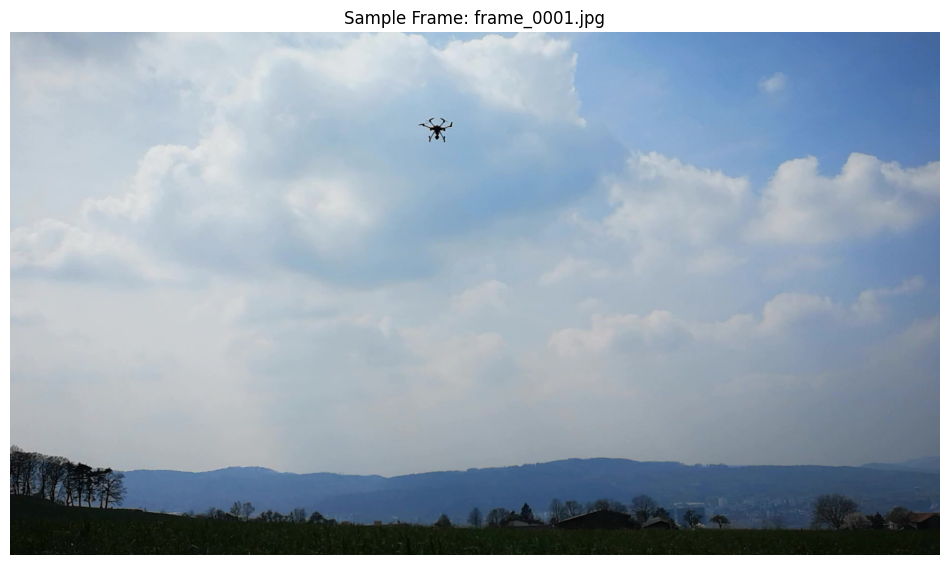

Frame dimensions: 1920 x 1080 pixels


In [ ]:
# Display a sample frame
sample_frames_dir = list(Config.FRAMES_DIR.iterdir())
if sample_frames_dir:
    sample_frame = list(sample_frames_dir[0].glob("frame_*.jpg"))[0]
    img = cv2.imread(str(sample_frame))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Sample Frame: {sample_frame.name}")
    plt.axis('off')
    plt.show()

    print(f"Frame dimensions: {img.shape[1]} x {img.shape[0]} pixels")

---
## Step 1.5: Fine-tune YOLOv8 on Drone Dataset

The drone dataset (`models/drone_finetune_data/`) is already prepared on disk.
Run these cells on **Google Colab (T4 GPU)** — estimated ~5 minutes.

After training, download `models/drone_finetune/weights/best.pt` and place it back
in the same path locally. The model select cell will pick it up automatically.

In [11]:
import yaml

FINETUNE_DIR = Config.MODELS_DIR / "drone_finetune_data"
DATASET_YAML = FINETUNE_DIR / "dataset.yaml"
FINETUNED_WEIGHTS = Config.MODELS_DIR / "drone_finetune" / "weights" / "best.pt"

if not DATASET_YAML.exists():
    print("[FAIL] Dataset not found at:", FINETUNE_DIR)
else:
    if FINETUNED_WEIGHTS.exists():
        print("[OK] Fine-tuned weights already exist:", FINETUNED_WEIGHTS)
    else:
        # Fix hardcoded path in dataset.yaml before training
        with open(DATASET_YAML) as f:
            data = yaml.safe_load(f)
        data["path"] = str(FINETUNE_DIR)
        with open(DATASET_YAML, "w") as f:
            yaml.dump(data, f)
        print("Updated dataset.yaml path to:", FINETUNE_DIR)

        print(f"Starting fine-tuning on {Config.DEVICE}...")
        ft_model = YOLO("yolov8n.pt")
        ft_model.train(
            data=str(DATASET_YAML),
            epochs=30,
            imgsz=640,
            batch=16,
            device=Config.DEVICE,
            project=str(Config.MODELS_DIR),
            name="drone_finetune",
            exist_ok=True,
            patience=10,
        )

        if FINETUNED_WEIGHTS.exists():
            print(f"\n[OK] Training complete! Best weights: {FINETUNED_WEIGHTS}")
        else:
            print("\n[FAIL] best.pt not found — check training output above.")

Updated dataset.yaml path to: /content/models/drone_finetune_data
Starting fine-tuning on cuda...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/models/drone_finetune_data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=d

In [6]:
# Use fine-tuned weights if available, otherwise fall back to pretrained
FINETUNED_WEIGHTS = Config.MODELS_DIR / "drone_finetune" / "weights" / "best.pt"

if FINETUNED_WEIGHTS.exists():
    Config.YOLO_MODEL = str(FINETUNED_WEIGHTS)
    print(f"Using fine-tuned model: {Config.YOLO_MODEL}")
else:
    print(f"Using pretrained model: {Config.YOLO_MODEL}")
    print("  Run the training cell above on Colab to improve accuracy.")

Using fine-tuned model: /workspaces/eng-ai-agents/assignments/assignments-3/models/drone_finetune/weights/best.pt


## Step 2: Task 1 - Drone Object Detection (50 points)



In [7]:
class DroneDetector:
    """
    Drone detector using YOLOv8.
    """

    def __init__(
        self,
        model_path: str = Config.YOLO_MODEL,
        confidence_threshold: float = Config.CONFIDENCE_THRESHOLD,
        iou_threshold: float = Config.IOU_THRESHOLD,
        device: str = Config.DEVICE
    ):
        """
        Initialize the detector.
        """
        self.confidence_threshold = confidence_threshold
        self.iou_threshold = iou_threshold
        self.device = device

        print(f"Loading YOLO model: {model_path}")
        print(f"  Device: {device}")
        print(f"  Confidence threshold: {confidence_threshold}")

        self.model = YOLO(model_path)
        self.class_names = self.model.names

        print(f"Model loaded!")
        print(f"  Available classes: {list(self.class_names.values())[:10]}...")

    def detect(self, image: np.ndarray) -> List[Dict]:
        """
        Detect objects in a single image.
        """
        results = self.model(
            image,
            conf=self.confidence_threshold,
            iou=self.iou_threshold,
            device=self.device,
            verbose=False
        )

        detections = []

        for result in results:
            boxes = result.boxes

            if boxes is None or len(boxes) == 0:
                continue

            for i in range(len(boxes)):
                bbox = boxes.xyxy[i].cpu().numpy()
                x1, y1, x2, y2 = bbox.astype(int)

                conf = float(boxes.conf[i].cpu().numpy())
                class_id = int(boxes.cls[i].cpu().numpy())
                class_name = self.class_names[class_id]

                # Calculate center (needed for Kalman filter)
                cx = (x1 + x2) / 2
                cy = (y1 + y2) / 2

                detection = {
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'center': [float(cx), float(cy)],
                    'confidence': conf,
                    'class_id': class_id,
                    'class_name': class_name,
                    'width': int(x2 - x1),
                    'height': int(y2 - y1)
                }

                detections.append(detection)

        return detections

In [8]:
def filter_drone_detections(
    detections: List[Dict],
    target_classes: List[str] = None
) -> List[Dict]:
    """
    Filter detections to keep only drone-related objects.
    """
    if target_classes is None:
        # Default: drone + proxy classes
        target_classes = ['drone']

    target_lower = [c.lower() for c in target_classes]

    return [
        det for det in detections
        if det['class_name'].lower() in target_lower
    ]

In [9]:
# Initialize detector
print("="*60)
print("INITIALIZING DRONE DETECTOR")
print("="*60)

# Change device to 'cpu' if you don't have CUDA
detector = DroneDetector(
    model_path=Config.YOLO_MODEL,
    confidence_threshold=Config.CONFIDENCE_THRESHOLD,
    device='cpu'  # Change to 'cuda' if you have GPU
)

INITIALIZING DRONE DETECTOR
Loading YOLO model: /workspaces/eng-ai-agents/assignments/assignments-3/models/drone_finetune/weights/best.pt
  Device: cpu
  Confidence threshold: 0.1
Model loaded!
  Available classes: ['drone']...



Testing detection on sample frame...

Found 1 objects:
  - drone: 0.50


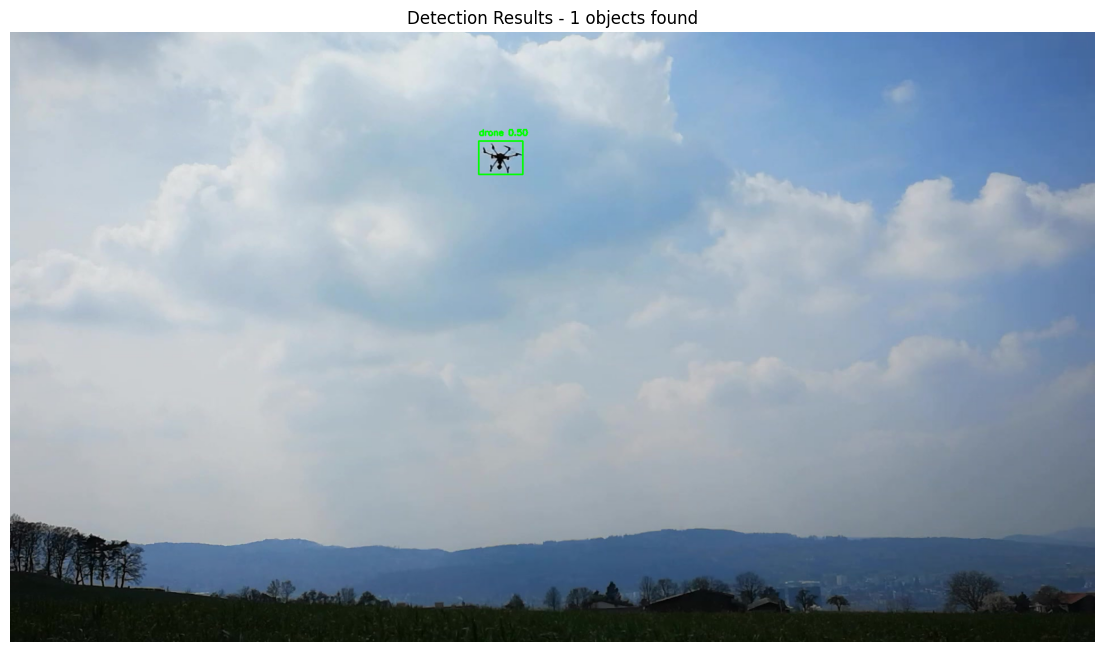

In [10]:
# Test detection on a sample frame
print("\nTesting detection on sample frame...")

sample_frames_dirs = [d for d in Config.FRAMES_DIR.iterdir() if d.is_dir()]
if sample_frames_dirs:
    sample_frame_path = list(sample_frames_dirs[0].glob("frame_*.jpg"))[10]
    sample_img = cv2.imread(str(sample_frame_path))

    # Run detection
    detections = detector.detect(sample_img)
    print(f"\nFound {len(detections)} objects:")
    for det in detections[:5]:  # Show first 5
        print(f"  - {det['class_name']}: {det['confidence']:.2f}")

    # Visualize
    vis_img = sample_img.copy()
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"{det['class_name']} {det['confidence']:.2f}"
        cv2.putText(vis_img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.figure(figsize=(14, 10))
    plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detection Results - {len(detections)} objects found")
    plt.axis('off')
    plt.show()

In [11]:
def process_video_frames(
    frames_dir: Path,
    detector: DroneDetector,
    detections_dir: Path,
    target_classes: List[str] = None
) -> Dict:
    """
    Process all frames from a video directory.

    Parameters:
    -----------
    frames_dir : Path
        Directory containing extracted frames
    detector : DroneDetector
        Initialized detector
    detections_dir : Path
        Where to save detection frames
    target_classes : List[str]
        Classes to consider as drones

    Returns:
    --------
    Dict : Detection results
    """
    video_name = frames_dir.name
    print(f"\nProcessing: {video_name}")

    frame_files = sorted(frames_dir.glob("frame_*.jpg"))

    if not frame_files:
        print(f"  [FAIL] No frames found")
        return None

    print(f"  Total frames: {len(frame_files)}")

    # Create output directory
    video_detections_dir = detections_dir / video_name
    video_detections_dir.mkdir(parents=True, exist_ok=True)

    results = {
        'video_name': video_name,
        'frames': {},
        'total_frames': len(frame_files),
        'frames_with_detections': 0
    }

    for frame_path in tqdm(frame_files, desc="  Detecting"):
        frame_num = int(frame_path.stem.split('_')[1])

        image = cv2.imread(str(frame_path))
        if image is None:
            continue

        # Detect
        detections = detector.detect(image)
        drone_detections = filter_drone_detections(detections, target_classes)

        results['frames'][frame_num] = drone_detections

        # Save frames with detections
        if drone_detections:
            results['frames_with_detections'] += 1

            annotated = image.copy()
            for det in drone_detections:
                x1, y1, x2, y2 = det['bbox']
                cv2.rectangle(annotated, (x1, y1), (x2, y2), Config.BOX_COLOR, 2)
                label = f"{det['class_name']} {det['confidence']:.2f}"
                cv2.putText(annotated, label, (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

            output_path = video_detections_dir / f"detection_{frame_num:04d}.jpg"
            cv2.imwrite(str(output_path), annotated)

    rate = results['frames_with_detections'] / results['total_frames'] * 100
    print(f"  [OK] Detections: {results['frames_with_detections']} frames ({rate:.1f}%)")

    return results

In [12]:
# Process all videos
print("="*60)
print("RUNNING DETECTION ON ALL VIDEOS")
print("="*60)

# Define target classes
# For pretrained model, use proxy classes
# For fine-tuned model, use ['drone']
TARGET_CLASSES = ['drone']
print(f"Target classes: {TARGET_CLASSES}\n")

frame_dirs = [d for d in Config.FRAMES_DIR.iterdir() if d.is_dir()]
all_results = []

for frames_dir in frame_dirs:
    results = process_video_frames(
        frames_dir=frames_dir,
        detector=detector,
        detections_dir=Config.DETECTIONS_DIR,
        target_classes=TARGET_CLASSES
    )
    if results:
        all_results.append(results)

print("\n[OK] Detection complete!")

RUNNING DETECTION ON ALL VIDEOS
Target classes: ['drone']


Processing: drone_video_1
  Total frames: 828


  Detecting:   0%|          | 0/828 [00:00<?, ?it/s]

  [OK] Detections: 684 frames (82.6%)

Processing: drone_video_2
  Total frames: 2580


  Detecting:   0%|          | 0/2580 [00:00<?, ?it/s]

  [OK] Detections: 722 frames (28.0%)

[OK] Detection complete!


In [13]:
# Save detection results for tracking
def save_detection_results(results: List[Dict], output_path: Path):
    """Save detection results to JSON."""
    output_data = []
    for video_result in results:
        if video_result is None:
            continue
        frames_data = {str(k): v for k, v in video_result['frames'].items()}
        output_data.append({
            'video_name': video_result['video_name'],
            'total_frames': video_result['total_frames'],
            'frames_with_detections': video_result['frames_with_detections'],
            'frames': frames_data
        })

    with open(output_path, 'w') as f:
        json.dump(output_data, f, indent=2)

    print(f"[OK] Results saved: {output_path}")

if all_results:
    save_detection_results(all_results, Config.DATA_DIR / "detections.json")

[OK] Results saved: /workspaces/eng-ai-agents/assignments/assignments-3/data/detections.json


## Step 3: Task 2 - Kalman Filter Tracking (50 points)

In [14]:
class DroneTracker:
    """
    Kalman filter-based drone tracker.

    STATE VECTOR: [x, y, vx, vy]
    - x, y: Center of bounding box (pixels)
    - vx, vy: Velocity (pixels per frame)

    MOTION MODEL: Constant velocity
    - position_new = position + velocity × dt
    - velocity_new = velocity (constant)
    """

    def __init__(
        self,
        initial_position: Tuple[float, float],
        dt: float = 1.0,
        process_noise_pos: float = Config.PROCESS_NOISE_POSITION,
        process_noise_vel: float = Config.PROCESS_NOISE_VELOCITY,
        measurement_noise: float = Config.MEASUREMENT_NOISE,
        initial_uncertainty_pos: float = Config.INITIAL_UNCERTAINTY_POSITION,
        initial_uncertainty_vel: float = Config.INITIAL_UNCERTAINTY_VELOCITY
    ):
        """
        Initialize Kalman filter tracker.
        """
        # Initialize filterpy KalmanFilter
        # dim_x=4: [x, y, vx, vy]
        # dim_z=2: [x, y] (we only measure position)
        self.kf = KalmanFilter(dim_x=4, dim_z=2)

        # State Transition Matrix (F)
        # Encodes: new_pos = old_pos + velocity * dt
        self.kf.F = np.array([
            [1, 0, dt, 0],   # x' = x + vx*dt
            [0, 1, 0, dt],   # y' = y + vy*dt
            [0, 0, 1, 0],    # vx' = vx
            [0, 0, 0, 1]     # vy' = vy
        ])

        # Measurement Matrix (H)
        # We observe position only
        self.kf.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Covariance (Q)
        self.kf.Q = np.diag([process_noise_pos, process_noise_pos,
                            process_noise_vel, process_noise_vel])

        # Measurement Noise Covariance (R)
        self.kf.R = np.diag([measurement_noise, measurement_noise])

        # Initial State Covariance (P)
        self.kf.P = np.diag([initial_uncertainty_pos, initial_uncertainty_pos,
                            initial_uncertainty_vel, initial_uncertainty_vel])

        # Initial state (observed position, zero velocity)
        self.kf.x = np.array([
            [initial_position[0]],
            [initial_position[1]],
            [0],
            [0]
        ])

        # Tracking state
        self.frames_since_detection = 0
        self.max_frames_to_skip = Config.MAX_FRAMES_TO_SKIP
        self.is_active = True

        # History for visualization
        self.position_history = deque(maxlen=Config.TRAJECTORY_LENGTH)
        self.position_history.append(tuple(initial_position))

        self.last_bbox = None
        self.last_confidence = 0.0

    def predict(self) -> Tuple[float, float]:
        """
        PREDICT step: Estimate next state using motion model.
        """
        self.kf.predict()
        return (float(self.kf.x[0, 0]), float(self.kf.x[1, 0]))

    def update(self, measurement: Tuple[float, float],
               bbox: List[int] = None, confidence: float = 0.0):
        """
        UPDATE step: Correct state with new measurement.
        """
        z = np.array([[measurement[0]], [measurement[1]]])
        self.kf.update(z)

        self.frames_since_detection = 0

        updated_pos = (float(self.kf.x[0, 0]), float(self.kf.x[1, 0]))
        self.position_history.append(updated_pos)

        if bbox:
            self.last_bbox = bbox
        self.last_confidence = confidence

    def update_without_detection(self):
        """
        Handle missing detection: use prediction only.
        """
        self.frames_since_detection += 1

        pred_pos = (float(self.kf.x[0, 0]), float(self.kf.x[1, 0]))
        self.position_history.append(pred_pos)

        if self.frames_since_detection > self.max_frames_to_skip:
            self.is_active = False

    def get_state(self) -> Dict:
        """Get current estimated state."""
        return {
            'position': (float(self.kf.x[0, 0]), float(self.kf.x[1, 0])),
            'velocity': (float(self.kf.x[2, 0]), float(self.kf.x[3, 0])),
            'is_active': self.is_active,
            'frames_since_detection': self.frames_since_detection,
            'confidence': self.last_confidence,
            'bbox': self.last_bbox
        }

    def get_trajectory(self) -> List[Tuple[float, float]]:
        """Get trajectory history for visualization."""
        return list(self.position_history)

In [15]:
def draw_tracking_overlay(
    image: np.ndarray,
    tracker: DroneTracker,
    detection: Optional[Dict] = None
) -> np.ndarray:
    """
    Draw tracking visualization on image.

    Elements:
    1. Bounding box (green=detected, orange=predicted)
    2. Trajectory polyline (blue)
    3. Velocity vector (magenta arrow)
    4. Position crosshair (yellow)
    """
    output = image.copy()
    state = tracker.get_state()

    # Draw trajectory
    trajectory = tracker.get_trajectory()
    if len(trajectory) >= 2:
        points = np.array([(int(x), int(y)) for x, y in trajectory], dtype=np.int32)
        cv2.polylines(output, [points], False, Config.TRAJECTORY_COLOR,
                     Config.TRAJECTORY_THICKNESS, cv2.LINE_AA)
        for pt in points[-10:]:
            cv2.circle(output, tuple(pt), 3, Config.TRAJECTORY_COLOR, -1)

    # Draw position crosshair
    pos = state['position']
    cx, cy = int(pos[0]), int(pos[1])
    cv2.line(output, (cx-10, cy), (cx+10, cy), (0, 255, 255), 2)
    cv2.line(output, (cx, cy-10), (cx, cy+10), (0, 255, 255), 2)

    # Draw bounding box
    bbox = detection['bbox'] if detection else state['bbox']
    if bbox:
        x1, y1, x2, y2 = bbox
        if detection:
            color = Config.BOX_COLOR  # Green
            label = f"Detected: {detection['confidence']:.2f}"
        else:
            color = (0, 165, 255)  # Orange
            label = f"Predicted (skip: {state['frames_since_detection']})"

        cv2.rectangle(output, (x1, y1), (x2, y2), color, Config.BOX_THICKNESS)
        cv2.putText(output, label, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

    # Draw velocity vector
    velocity = state['velocity']
    if abs(velocity[0]) > 0.1 or abs(velocity[1]) > 0.1:
        end_x = int(cx + velocity[0] * 5)
        end_y = int(cy + velocity[1] * 5)
        cv2.arrowedLine(output, (cx, cy), (end_x, end_y), (255, 0, 255), 2)

    return output

In [16]:
def load_detection_results(json_path: Path) -> Dict:
    """Load detection results from JSON."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    results = {}
    for video_data in data:
        video_name = video_data['video_name']
        frames = {int(k): v for k, v in video_data['frames'].items()}
        results[video_name] = {
            'frames': frames,
            'total_frames': video_data['total_frames'],
            'frames_with_detections': video_data['frames_with_detections']
        }
    return results


def find_best_detection(detections: List[Dict]) -> Optional[Dict]:
    """Find highest confidence detection."""
    if not detections:
        return None
    return max(detections, key=lambda d: d['confidence'])

In [17]:
def process_video_tracking(
    video_name: str,
    detection_data: Dict,
    frames_dir: Path,
    output_dir: Path
) -> Dict:
    """
    Process a video with Kalman filter tracking.

    Parameters:
    -----------
    video_name : str
        Name of video
    detection_data : Dict
        Detection results
    frames_dir : Path
        Directory with frames
    output_dir : Path
        Where to save output video

    Returns:
    --------
    Dict : Tracking statistics
    """
    print(f"\nTracking: {video_name}")

    video_frames_dir = frames_dir / video_name
    frame_files = sorted(video_frames_dir.glob("frame_*.jpg"))

    if not frame_files:
        print("  [FAIL] No frames found")
        return None

    # Get video dimensions
    first_frame = cv2.imread(str(frame_files[0]))
    height, width = first_frame.shape[:2]

    # Initialize video writer
    output_path = output_dir / f"{video_name}_tracked.mp4"
    fourcc = cv2.VideoWriter_fourcc(*Config.OUTPUT_CODEC)
    video_writer = cv2.VideoWriter(
        str(output_path), fourcc, Config.OUTPUT_FPS, (width, height)
    )

    tracker = None
    frames_detections = detection_data['frames']

    stats = {
        'video_name': video_name,
        'total_frames': len(frame_files),
        'frames_with_drone': 0,
        'frames_tracked': 0,
        'frames_predicted': 0
    }

    print(f"  Frames: {len(frame_files)}")

    for frame_path in tqdm(frame_files, desc="  Tracking"):
        frame_num = int(frame_path.stem.split('_')[1])
        frame = cv2.imread(str(frame_path))

        if frame is None:
            continue

        frame_detections = frames_detections.get(frame_num, [])
        best_detection = find_best_detection(frame_detections)

        if best_detection:
            stats['frames_with_drone'] += 1
            center = tuple(best_detection['center'])

            if tracker is None:
                # Initialize tracker
                tracker = DroneTracker(initial_position=center)
            else:
                tracker.predict()
                tracker.update(
                    measurement=center,
                    bbox=best_detection['bbox'],
                    confidence=best_detection['confidence']
                )
            stats['frames_tracked'] += 1

        elif tracker is not None and tracker.is_active:
            # No detection, predict only
            tracker.predict()
            tracker.update_without_detection()
            stats['frames_predicted'] += 1

        # Draw overlay and write frame
        if tracker is not None and tracker.is_active:
            frame = draw_tracking_overlay(frame, tracker, best_detection)
            video_writer.write(frame)
        elif best_detection:
            video_writer.write(frame)

    video_writer.release()

    print(f"  Output: {output_path.name}")
    print(f"    Tracked: {stats['frames_tracked']}, Predicted: {stats['frames_predicted']}")

    return stats

In [18]:
# Run tracking on all videos
print("="*60)
print("KALMAN FILTER TRACKING")
print("="*60)

# Load detection results
detection_path = Config.DATA_DIR / "detections.json"

if not detection_path.exists():
    print("[FAIL] Detection results not found!")
    print("  Run detection cells first.")
else:
    detection_results = load_detection_results(detection_path)
    print(f"Loaded {len(detection_results)} video(s)")

    print(f"\nKalman Filter Parameters:")
    print(f"  Process noise (position): {Config.PROCESS_NOISE_POSITION}")
    print(f"  Process noise (velocity): {Config.PROCESS_NOISE_VELOCITY}")
    print(f"  Measurement noise: {Config.MEASUREMENT_NOISE}")
    print(f"  Max frames to skip: {Config.MAX_FRAMES_TO_SKIP}")

    all_stats = []
    for video_name, detection_data in detection_results.items():
        stats = process_video_tracking(
            video_name=video_name,
            detection_data=detection_data,
            frames_dir=Config.FRAMES_DIR,
            output_dir=Config.OUTPUT_DIR
        )
        if stats:
            all_stats.append(stats)

    print("\n" + "="*60)
    print("TRACKING COMPLETE!")
    print("="*60)
    print(f"\nOutput videos: {Config.OUTPUT_DIR}/")

KALMAN FILTER TRACKING
Loaded 2 video(s)

Kalman Filter Parameters:
  Process noise (position): 1.0
  Process noise (velocity): 0.1
  Measurement noise: 10.0
  Max frames to skip: 10

Tracking: drone_video_1
  Frames: 828


  Tracking:   0%|          | 0/828 [00:00<?, ?it/s]

  Output: drone_video_1_tracked.mp4
    Tracked: 684, Predicted: 17

Tracking: drone_video_2
  Frames: 2580


  Tracking:   0%|          | 0/2580 [00:00<?, ?it/s]

  Output: drone_video_2_tracked.mp4
    Tracked: 722, Predicted: 11

TRACKING COMPLETE!

Output videos: /workspaces/eng-ai-agents/assignments/assignments-3/output/


# PARQUET DATASET

In [19]:
def create_parquet_dataset(detections_dir: Path, data_dir: Path) -> pd.DataFrame:
    """
    Create Parquet dataset from detection frames.
    
    Parameters:
    -----------
    detections_dir : Path
        Directory with detection frames
    data_dir : Path
        Where to save Parquet file
    
    Returns:
    --------
    pd.DataFrame : The dataset
    """
    print("Creating Parquet dataset...")
    
    # Load detection metadata
    json_path = data_dir / "detections.json"
    metadata = {}
    if json_path.exists():
        with open(json_path, 'r') as f:
            data = json.load(f)
        for video_data in data:
            video_name = video_data['video_name']
            metadata[video_name] = {}
            for frame_str, dets in video_data['frames'].items():
                if dets:
                    metadata[video_name][int(frame_str)] = dets
    
    # Collect samples
    records = []
    for video_dir in detections_dir.iterdir():
        if not video_dir.is_dir():
            continue
        
        video_name = video_dir.name
        print(f"  Processing: {video_name}")
        
        for img_path in sorted(video_dir.glob("detection_*.jpg")):
            frame_num = int(img_path.stem.split('_')[1])
            dets = metadata.get(video_name, {}).get(frame_num, [])
            
            record = {
                'video_name': video_name,
                'frame_number': frame_num,
                'image_path': str(img_path),
                'num_detections': len(dets)
            }
            
            if dets:
                det = dets[0]
                record.update({
                    'bbox_x1': det['bbox'][0],
                    'bbox_y1': det['bbox'][1],
                    'bbox_x2': det['bbox'][2],
                    'bbox_y2': det['bbox'][3],
                    'center_x': det['center'][0],
                    'center_y': det['center'][1],
                    'confidence': det['confidence'],
                    'class_name': det['class_name']
                })
            
            records.append(record)
    
    df = pd.DataFrame(records)
    
    # Save Parquet
    parquet_path = data_dir / "drone_detections.parquet"
    df.to_parquet(parquet_path, index=False)
    
    print(f"\n Saved: {parquet_path}")
    print(f"  Records: {len(df)}")
    print(f"  Columns: {list(df.columns)}")
    
    return df

In [20]:
# Create the dataset
print("="*60)
print("CREATING HUGGINGFACE DATASET")
print("="*60)

df = create_parquet_dataset(Config.DETECTIONS_DIR, Config.DATA_DIR)

# Display sample
if df is not None and len(df) > 0:
    print("\nSample records:")
    display(df.head())

CREATING HUGGINGFACE DATASET
Creating Parquet dataset...
  Processing: drone_video_1
  Processing: drone_video_2

 Saved: /workspaces/eng-ai-agents/assignments/assignments-3/data/drone_detections.parquet
  Records: 1406
  Columns: ['video_name', 'frame_number', 'image_path', 'num_detections', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2', 'center_x', 'center_y', 'confidence', 'class_name']

Sample records:


,video_name,frame_number,image_path,num_detections,bbox_x1,bbox_y1,bbox_x2,bbox_y2,center_x,center_y,confidence,class_name
0,drone_video_1,1,/workspaces/eng-ai-agents/assignments/assignme...,1,841,173,922,229,881.5,201.0,0.507883,drone
1,drone_video_1,2,/workspaces/eng-ai-agents/assignments/assignme...,1,848,176,923,234,885.5,205.0,0.487252,drone
2,drone_video_1,3,/workspaces/eng-ai-agents/assignments/assignme...,1,839,177,924,240,881.5,208.5,0.507304,drone
3,drone_video_1,4,/workspaces/eng-ai-agents/assignments/assignme...,1,837,182,920,244,878.5,213.0,0.501418,drone
4,drone_video_1,5,/workspaces/eng-ai-agents/assignments/assignme...,1,834,187,913,246,873.5,216.5,0.483298,drone
